# Mini-Project 4 — Rainfall Pattern & Crop Suitability Analyser

**Scenario.** An agricultural extension officer wants to compare rainfall regimes across regions and advise farmers on which months suit which crops.

The logic lives in [`src/rainfall.py`](src/rainfall.py):

| Class / function | Responsibility | OOP idea |
|---|---|---|
| `Region` | 12 monthly totals; annual total, mean, wettest/driest month, CV, rainy-season detection | Encapsulation (read-only array), `__repr__`, `__len__`, `__getitem__`, `__iter__` |
| `CropRule` | Suitable monthly range for one crop; classifies a month | Alternative constructor `from_seasonal_need` (`@classmethod`) |
| `SuitabilityAnalyser` | Applies many rules to many regions | Composition (*has* regions and rules) |
| `RainfallRecord` | Many years of real data → climatology `Region` + variability | Composition, `from_csv` factory |
| `cosine_similarity`, `pearson_correlation`, `euclidean_distance`, `pairwise_matrix` | Similarity measures | Functions passed as arguments (strategy) |

### Assumptions
1. The core tasks use the **illustrative** data from the brief. The extension uses **real NASA POWER data** (2014–2023), which is also used to check the illustrative data.
2. Crop thresholds are **monthly rainfall** ranges derived from published *seasonal* water needs spread evenly over the growing period (Task 2). Rainfall is not the same as water the crop can use: runoff, soil storage and evaporation are ignored.
3. "Waterlogging risk" means that month's rain exceeds the crop's upper water need, so the surplus must drain away. Whether fields actually waterlog depends on soil and slope, which this model does not know.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.spatial.distance import cosine as scipy_cosine_distance

from src.rainfall import (
    MONTHS, Region, CropRule, SuitabilityAnalyser, RainfallRecord, default_crop_rules,
    cosine_similarity, flawed_cosine_similarity, pearson_correlation, euclidean_distance, pairwise_matrix,
)

SEED = 2026                     # no randomness here; kept for consistency across notebooks
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
COLORS = {"Kampala": "#2F6690", "Gulu": "#B23A48", "Mbarara": "#3A7D44"}

## Task 1 — The `Region` class

In [2]:
raw = {
    "Kampala": [120, 140, 180, 200, 220, 180,  90,  70,  60, 100, 110, 130],
    "Gulu":    [  8,  25,  75, 160, 190, 145, 170, 215, 175, 150,  60,  15],
    "Mbarara": [ 70,  85, 120, 140,  90,  25,  20,  55, 100, 125, 120,  90],
}
regions = [Region(name, values) for name, values in raw.items()]
for r in regions:
    print(r)

summary = pd.DataFrame({
    r.name: {"annual total (mm)": r.annual_total(), "monthly mean (mm)": r.mean(),
             "wettest month": r.wettest_month(), "driest month": r.driest_month(),
             "CV across months": round(r.cv(), 3)}
    for r in regions
}).T
summary

Region('Kampala', annual=1,600 mm, unimodal)
Region('Gulu', annual=1,388 mm, unimodal)
Region('Mbarara', annual=1,040 mm, bimodal)


,annual total (mm),monthly mean (mm),wettest month,driest month,CV across months
Kampala,"1,600.00",133.33,May,Sep,0.39
Gulu,"1,388.00",115.67,Aug,Jan,0.64
Mbarara,"1,040.00",86.67,Apr,Jul,0.44


Kampala is the wettest overall (1,600 mm) and the **least seasonal** (CV ≈ 0.39): no month drops below 60 mm. Gulu has a similar total (1,388 mm) but the **most seasonal** regime (CV ≈ 0.64), with a near-rainless December–February. Mbarara is the driest (1,040 mm) and has a sharp June–July dry spell. The CV here measures how unevenly rain is spread through the year, which matters more to a farmer than the annual total.

## Task 2 — `CropRule` thresholds from cited sources, and month-by-month classification

In [3]:
rules = default_crop_rules()
pd.DataFrame([{"crop": r.crop, "min mm/month": r.min_mm, "max mm/month": r.max_mm, "source": r.source} for r in rules]).set_index("crop")

,min mm/month,max mm/month,source
crop,,,
maize,85.00,190.00,"FAO (1986) Irrigation Water Needs, Training Ma..."
beans,80.00,160.00,"FAO (1986) Irrigation Water Needs, Training Ma..."
coffee,55.00,200.00,UCDA (2019) Robusta Coffee Handbook


**How the thresholds were derived.**

| Crop | Published requirement | Monthly range used |
|---|---|---|
| Maize (grain) | 500–800 mm per season of 125–180 days (FAO 1986, Tables 4–5) | 500 mm ÷ 6 months ≈ **85** to 800 mm ÷ 4.2 months ≈ **190** |
| Beans (dry) | 300–500 mm per season of 95–110 days (FAO 1986, Tables 4–5) | 300 ÷ 3.7 ≈ **80** to 500 ÷ 3.2 ≈ **160** |
| Robusta coffee | 1,200–1,800 mm/yr "well distributed over a period of 9 months", plus ≈ 25 mm every 14 days to stimulate flowering (UCDA 2019) | lower bound 25 mm × 30/14 ≈ **55**; upper 1,800 ÷ 9 ≈ **200** |

The lower bound spreads the smallest need over the longest season, and the upper bound spreads the largest need over the shortest (`CropRule.from_seasonal_need`), so the range is deliberately generous. Coffee is perennial: its "good" months are months without stress, not planting months.

*Sources:* FAO (1986) *Irrigation Water Management: Irrigation Water Needs*, Training Manual No. 3, ch. 2; Uganda Coffee Development Authority (2019) *Robusta Coffee Handbook*.

In [4]:
analyser = SuitabilityAnalyser(regions, rules)
labels = pd.DataFrame(analyser.labels(), index=MONTHS).T
labels

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Kampala,"Good for maize, beans, coffee","Good for maize, beans, coffee","Good for maize, coffee",Good for coffee,Waterlogging risk,"Good for maize, coffee","Good for maize, beans, coffee",Good for coffee,Good for coffee,"Good for maize, beans, coffee","Good for maize, beans, coffee","Good for maize, beans, coffee"
Gulu,Drought risk,Drought risk,Good for coffee,"Good for maize, beans, coffee","Good for maize, coffee","Good for maize, beans, coffee","Good for maize, coffee",Waterlogging risk,"Good for maize, coffee","Good for maize, beans, coffee",Good for coffee,Drought risk
Mbarara,Good for coffee,"Good for maize, beans, coffee","Good for maize, beans, coffee","Good for maize, beans, coffee","Good for maize, beans, coffee",Drought risk,Drought risk,Good for coffee,"Good for maize, beans, coffee","Good for maize, beans, coffee","Good for maize, beans, coffee","Good for maize, beans, coffee"


In [5]:
detail = pd.DataFrame(analyser.detail(), index=MONTHS).T
short = {"Good": "✔ good", "Drought risk": "dry", "Waterlogging risk": "wet"}
detail.replace(short)

Jan     Feb     Mar     Apr     May     Jun     Jul  \
Kampala maize   ✔ good  ✔ good  ✔ good     wet     wet  ✔ good  ✔ good   
        beans   ✔ good  ✔ good     wet     wet     wet     wet  ✔ good   
        coffee  ✔ good  ✔ good  ✔ good  ✔ good     wet  ✔ good  ✔ good   
Gulu    maize      dry     dry     dry  ✔ good  ✔ good  ✔ good  ✔ good   
        beans      dry     dry     dry  ✔ good     wet  ✔ good     wet   
        coffee     dry     dry  ✔ good  ✔ good  ✔ good  ✔ good  ✔ good   
Mbarara maize      dry  ✔ good  ✔ good  ✔ good  ✔ good     dry     dry   
        beans      dry  ✔ good  ✔ good  ✔ good  ✔ good     dry     dry   
        coffee  ✔ good  ✔ good  ✔ good  ✔ good  ✔ good     dry     dry   

                   Aug     Sep     Oct     Nov     Dec  
Kampala maize      dry     dry  ✔ good  ✔ good  ✔ good  
        beans      dry     dry  ✔ good  ✔ good  ✔ good  
        coffee  ✔ good  ✔ good  ✔ good  ✔ good  ✔ good  
Gulu    maize      wet  ✔ good  ✔ good     dry     dry  
        beans      wet     wet  ✔ good     dry     dry  
        coffee     wet  ✔ good  ✔ good  ✔ good     dry  
Mbarara maize      dry  ✔ good  ✔ good  ✔ good  ✔ good  
        beans      dry  ✔ good  ✔ good  ✔ good  ✔ good  
        coffee  ✔ good  ✔ good  ✔ good  ✔ good  ✔ good

* **Kampala** is good for all three crops from October to February, has **waterlogging risk in May** (220 mm exceeds every crop's upper bound), and is too dry for maize and beans in August–September.
* **Gulu** has a hard **drought window from December to February**. April–October suits maize, but the August peak (215 mm) is too wet for every crop.
* **Mbarara** is dry in **June–July** for every crop, and has two good windows for maize and beans: **February–May** and **September–December**.

## Task 3 — Correcting last year's cosine similarity

In [6]:
k, g = regions[0].rainfall, regions[1].rainfall
print(f"Flawed  math.cos(k·g)       : Kampala vs Gulu    = {flawed_cosine_similarity(k, g):+.4f}")
print(f"Flawed  math.cos(k·k)       : Kampala vs ITSELF  = {flawed_cosine_similarity(k, k):+.4f}   <- should be 1")
print(f"Flawed  after adding 1 mm to Jan: {flawed_cosine_similarity(k + np.eye(12)[0], g):+.4f}   <- jumps wildly")
print()
ours = cosine_similarity(k, g)
theirs = 1 - scipy_cosine_distance(k, g)       # scipy returns the cosine DISTANCE = 1 - similarity
print(f"Correct dot/(|a||b|)        : Kampala vs Gulu    = {ours:.6f}")
print(f"scipy 1 - cosine distance   : Kampala vs Gulu    = {theirs:.6f}")
assert np.isclose(ours, theirs)
print(f"Correct                     : Kampala vs ITSELF  = {cosine_similarity(k, k):.6f}")

Flawed  math.cos(k·g)       : Kampala vs Gulu    = -0.8765
Flawed  math.cos(k·k)       : Kampala vs ITSELF  = +0.4268   <- should be 1
Flawed  after adding 1 mm to Jan: +0.6038   <- jumps wildly

Correct dot/(|a||b|)        : Kampala vs Gulu    = 0.786609
scipy 1 - cosine distance   : Kampala vs Gulu    = 0.786609
Correct                     : Kampala vs ITSELF  = 1.000000


`math.cos(x)` returns the cosine of an **angle** $x$ in radians. Passing it a dot product (or any number derived from the data) treats millimetres² as radians. The result swings between −1 and +1 as the input grows, so it gives a region a similarity of 0.43 *with itself*, and a 1 mm change can flip its sign.

Cosine *similarity* is the cosine of the angle **between two vectors**, obtained by rearranging the dot-product definition $a \cdot b = \|a\|\|b\|\cos\theta$:
$$\cos\theta = \frac{a\cdot b}{\|a\|\,\|b\|}.$$
It is 1 for vectors pointing the same way, 0 for perpendicular vectors and −1 for opposite ones. My implementation matches `scipy.spatial.distance.cosine` (which returns the *distance* $1 - \cos\theta$), and it raises an error for an all-zero vector, where the angle is undefined.

## Task 4 — Three similarity / distance matrices

In [7]:
names = [r.name for r in regions]
matrices = {
    "Cosine similarity": pairwise_matrix(regions, cosine_similarity),
    "Pearson correlation": pairwise_matrix(regions, pearson_correlation),
    "Euclidean distance (mm)": pairwise_matrix(regions, euclidean_distance),
}
assert np.allclose(matrices["Pearson correlation"], np.corrcoef([r.rainfall for r in regions]))   # second-method check
for title, m in matrices.items():
    print(f"\n{title}")
    display(pd.DataFrame(m, index=names, columns=names).round(3))


Cosine similarity


,Kampala,Gulu,Mbarara
Kampala,1.00,0.79,0.89
Gulu,0.79,1.00,0.75
Mbarara,0.89,0.75,1.00



Pearson correlation


,Kampala,Gulu,Mbarara
Kampala,1.00,-0.07,0.21
Gulu,-0.07,1.00,-0.17
Mbarara,0.21,-0.17,1.00



Euclidean distance (mm)


,Kampala,Gulu,Mbarara
Kampala,0.00,315.27,250.40
Gulu,315.27,0.00,312.80
Mbarara,250.40,312.80,0.00


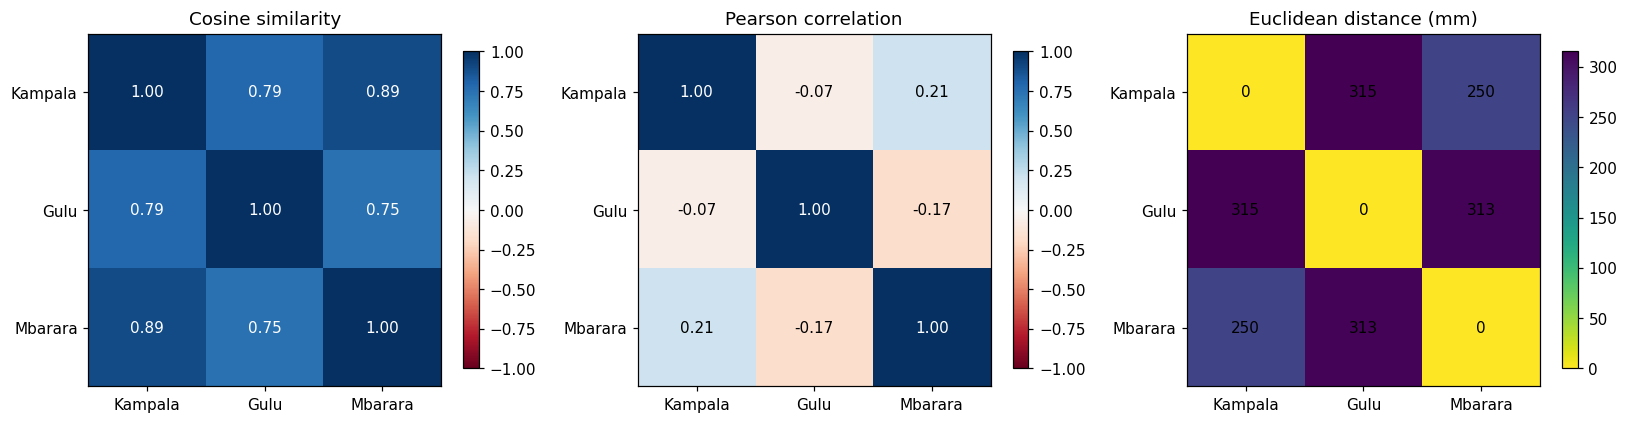

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, m) in zip(axes, matrices.items()):
    cmap = "viridis_r" if "Euclidean" in title else "RdBu"
    vmin, vmax = (0, m.max()) if "Euclidean" in title else (-1, 1)
    im = ax.imshow(m, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3), names); ax.set_yticks(range(3), names); ax.grid(False)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{m[i, j]:.2f}" if "Euclid" not in title else f"{m[i, j]:.0f}", ha="center", va="center",
                    color="white" if (abs(m[i, j]) > 0.6 and "Euclid" not in title) else "black")
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout(); fig.savefig("figures/p4_similarity.png", bbox_inches="tight")
plt.show()

In [9]:
# Demonstration: a region that is simply 3x wetter than Kampala, with identical timing
wet_kampala = 3 * regions[0].rainfall
print(f"Kampala vs '3x Kampala': cosine = {cosine_similarity(regions[0].rainfall, wet_kampala):.3f}, "
      f"Pearson = {pearson_correlation(regions[0].rainfall, wet_kampala):.3f}, "
      f"Euclidean = {euclidean_distance(regions[0].rainfall, wet_kampala):,.0f} mm")

Kampala vs '3x Kampala': cosine = 1.000, Pearson = 1.000, Euclidean = 985 mm


**The three measures disagree, and the disagreement is informative.**

* **Cosine** rates every pair as fairly similar (0.75–0.89), including Kampala and Gulu (0.79).
* **Pearson** says Kampala and Gulu have essentially **unrelated or opposite timing** (r ≈ −0.07), and Gulu and Mbarara are negatively related (r ≈ −0.17).
* **Euclidean** says the biggest gap is Kampala–Gulu (≈ 315 mm).

**Why cosine can call a much wetter region "similar".** Cosine looks only at the *direction* of the 12-month vector, not its length, so multiplying a region's rainfall by any positive factor leaves it unchanged. A region three times wetter than Kampala scores exactly 1.00, even though it is about 985 mm away in Euclidean terms. Rainfall is also never negative, so every vector lies in the same "all-positive" corner of 12-D space. The angle between any two such vectors is therefore small, and cosine stays high whatever the seasonal timing. Pearson correlation is the cosine of the **mean-centred** vectors: it removes the common "it rains every month" component and compares only the *shape* of the seasonal cycle. Euclidean distance compares actual amounts.

**For agronomy, use Pearson for seasonal timing and Euclidean (or annual totals) for the amount of water, not raw cosine.**

## Task 5 — Automatic rainy-season detection with `scipy.signal.find_peaks`

In [10]:
rows = []
for r in regions:
    all_peaks = r.rainy_seasons(min_relative_prominence=0.0)
    kept = r.rainy_seasons()
    rows.append({
        "region": r.name,
        "all local peaks (month: rel. prominence)": ", ".join(f"{s.month}: {s.relative_prominence:.2f}" for s in all_peaks),
        f"seasons kept (≥ {Region.SEASON_THRESHOLD})": ", ".join(s.month for s in kept),
        "classification": r.modality(),
    })
pd.DataFrame(rows).set_index("region")

,all local peaks (month: rel. prominence),seasons kept (≥ 0.3),classification
region,,,
Kampala,"May: 1.00, Dec: 0.06",May,unimodal
Gulu,"May: 0.22, Aug: 1.00",Aug,unimodal
Mbarara,"Apr: 1.00, Oct: 0.46","Apr, Oct",bimodal


**Method.** A plain `find_peaks` call on 12 values cannot see a peak in December or January, because the ends of an array are never peaks, and it treats every tiny bump as a peak. So I (i) tile the year three times and keep peaks from the middle copy, which makes the calendar circular; and (ii) require a **prominence** of at least 30 % of the region's annual range. Prominence is how far a peak rises above the lowest point separating it from a higher peak. The 30 % threshold means a second peak must be separated by a genuine dry spell, deep enough that farmers would treat it as a separate planting season.

**Checking against Uganda's known climate zones** (UNMA; also visible in the 10-year NASA POWER record below). The Lake Victoria basin (Kampala) and the south-west (Mbarara) are **bimodal**, with long rains in March–May and short rains in September–November. The north (Gulu) is **unimodal**, with one long wet season from about April to October/November, sometimes interrupted by a slight June–July dip.

In [11]:
thresholds = [0.05, 0.10, 0.20, 0.25, 0.30, 0.40, 0.50]
sens = pd.DataFrame({t: [r.modality(t) for r in regions] for t in thresholds}, index=names)
sens.columns = [f"≥{t:.2f}" for t in thresholds]
sens.loc[:, "expected (known zone)"] = ["bimodal", "unimodal", "bimodal"]
sens

,≥0.05,≥0.10,≥0.20,≥0.25,≥0.30,≥0.40,≥0.50,expected (known zone)
Kampala,bimodal,unimodal,unimodal,unimodal,unimodal,unimodal,unimodal,bimodal
Gulu,bimodal,bimodal,bimodal,unimodal,unimodal,unimodal,unimodal,unimodal
Mbarara,bimodal,bimodal,bimodal,bimodal,bimodal,bimodal,unimodal,bimodal


* **Mbarara → bimodal ✔** (April and October peaks). This is robust for any threshold up to about 0.45.
* **Gulu → unimodal ✔.** Its May peak is only a *shoulder* (relative prominence 0.22) before the main August peak, which matches the known northern regime. At a threshold of 0.2 or lower it would wrongly be counted as bimodal, which is why the threshold is needed.
* **Kampala → unimodal ✘.** This is the one mismatch, and the cause is the **data, not the detector**. In the illustrative series the short rains barely exist: October–December rise only to 130 mm, the "dry" gap before them never falls below 60 mm, and January–February (120–140 mm) are *wetter* than November. Real Kampala has dry January–February and wet October–November (see the extension). The December bump has a relative prominence of only 0.06, so no sensible threshold can call it a season. The detector finds Kampala **bimodal** when run on real data.

## Task 6 — (a) Rainfall regimes on one chart and (b) crop-suitability heatmap

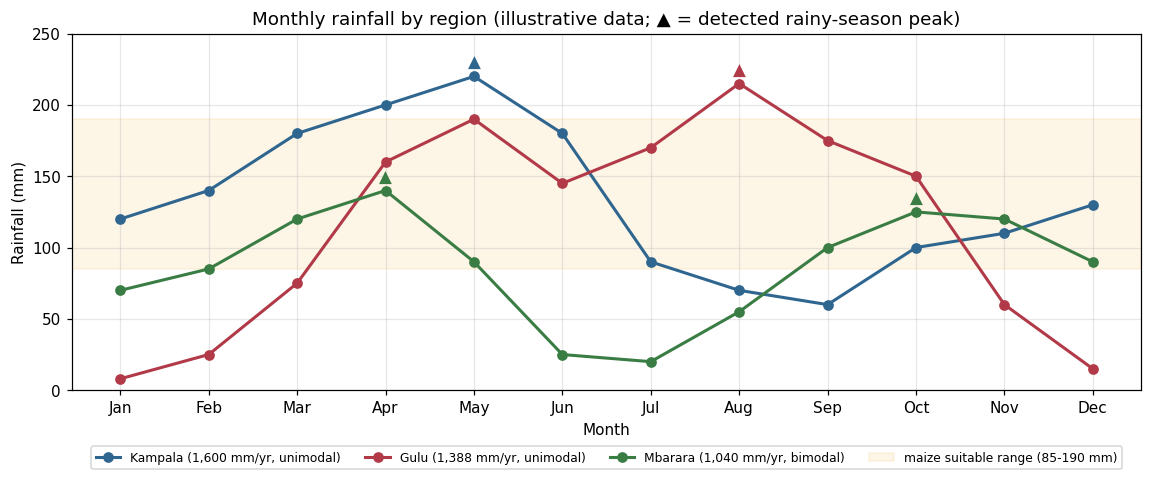

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for r in regions:
    ax.plot(MONTHS, r.rainfall, marker="o", lw=2, color=COLORS[r.name],
            label=f"{r.name} ({r.annual_total():,.0f} mm/yr, {r.modality()})")
    for s in r.rainy_seasons():
        ax.annotate("▲", (MONTHS.index(s.month), s.rainfall + 6), ha="center", color=COLORS[r.name], fontsize=11)
maize = rules[0]
ax.axhspan(maize.min_mm, maize.max_mm, color="#F2B134", alpha=0.12, label=f"maize suitable range ({maize.min_mm:.0f}-{maize.max_mm:.0f} mm)")
ax.set(title="Monthly rainfall by region (illustrative data; ▲ = detected rainy-season peak)", xlabel="Month", ylabel="Rainfall (mm)", ylim=(0, 250))
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=4)
fig.tight_layout(); fig.savefig("figures/p4_rainfall_lines.png", bbox_inches="tight")
plt.show()

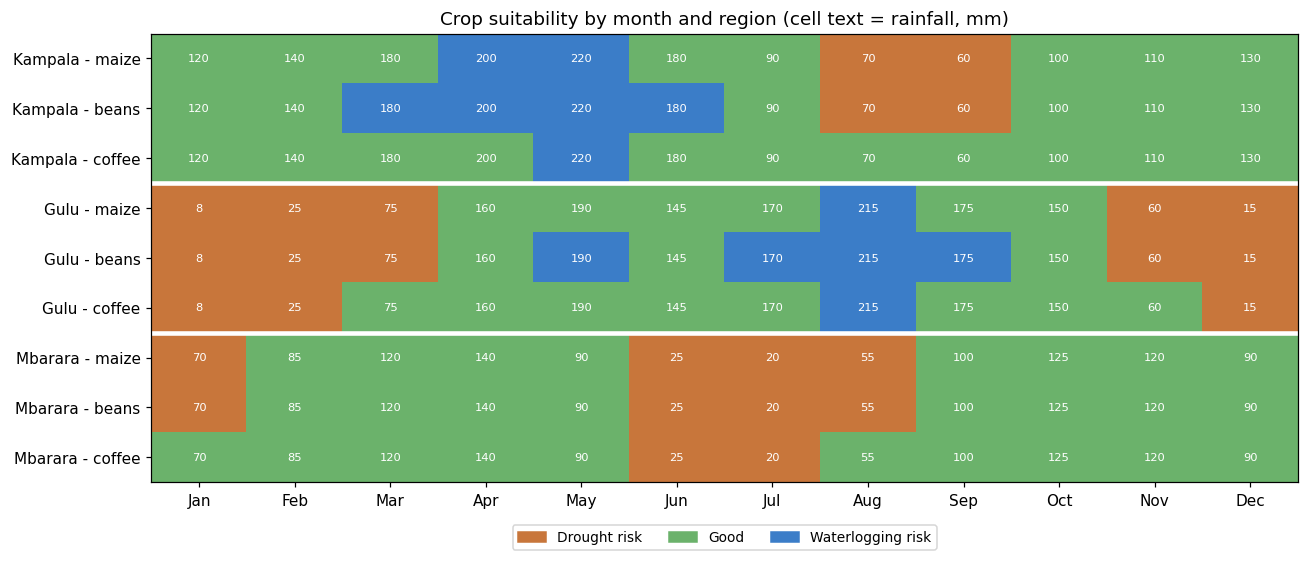

In [13]:
grid, row_labels = analyser.score_grid()
rain_rows = np.array([reg.rainfall for reg in regions for _ in rules])
cmap = ListedColormap(["#C8763B", "#6BB26B", "#3B7DC8"])          # drought / good / waterlogging
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.imshow(grid, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(12), MONTHS); ax.set_yticks(range(len(row_labels)), row_labels); ax.grid(False)
for i in range(grid.shape[0]):
    for j in range(12):
        ax.text(j, i, f"{rain_rows[i, j]:.0f}", ha="center", va="center", fontsize=7.5, color="white")
for boundary in np.arange(len(rules), grid.shape[0], len(rules)):
    ax.axhline(boundary - 0.5, color="white", lw=3)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cmap.colors]
ax.legend(handles, ["Drought risk", "Good", "Waterlogging risk"], loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=9)
ax.set_title("Crop suitability by month and region (cell text = rainfall, mm)")
fig.tight_layout(); fig.savefig("figures/p4_suitability_heatmap.png", bbox_inches="tight")
plt.show()

## Extension — Real NASA POWER rainfall, 2014–2023

**Data.** NASA POWER monthly point data (API v2.10, parameter `PRECTOTCORR_SUM`, community AG), a bias-corrected MERRA-2 reanalysis product, at Kampala (0.348° N, 32.583° E), Gulu (2.772° N, 32.288° E) and Mbarara (0.607° S, 30.654° E), 2014–2023. That is 360 monthly values in `data/nasa_power_monthly_rainfall.csv`. When the data were saved, every year's 12 months were checked against POWER's own annual total, and the whole file against a checksum computed from the API response.

Source: NASA Langley Research Center (LaRC) POWER Project, funded through the NASA Earth Science/Applied Science Program, https://power.larc.nasa.gov. Note that the API labels `PRECTOTCORR_SUM` as "mm/day", but the values are monthly totals: they sum exactly to the annual (month-13) value.

In [14]:
records = RainfallRecord.from_csv("data/nasa_power_monthly_rainfall.csv")
real = {name: rec.climatology() for name, rec in records.items()}
for name, rec in records.items():
    clim = real[name]
    print(f"{rec!r}: mean {clim.annual_total():,.0f} mm/yr (range {rec.annual_totals().min():,.0f}-{rec.annual_totals().max():,.0f}), "
          f"{clim.modality()} with peaks in {', '.join(s.month for s in clim.rainy_seasons())}")

compare = pd.DataFrame({
    name: {"illustrative total (mm)": reg.annual_total(), "NASA 10-yr mean (mm)": real[name].annual_total(),
           "illustrative modality": reg.modality(), "real modality": real[name].modality(),
           "Pearson r (illustrative vs real)": pearson_correlation(reg.rainfall, real[name].rainfall)}
    for name, reg in zip(names, regions)
}).T
compare

RainfallRecord('Kampala', 2014-2023, n_years=10): mean 1,506 mm/yr (range 1,107-1,841), bimodal with peaks in Apr, Nov
RainfallRecord('Gulu', 2014-2023, n_years=10): mean 1,416 mm/yr (range 1,109-2,128), unimodal with peaks in Oct
RainfallRecord('Mbarara', 2014-2023, n_years=10): mean 1,314 mm/yr (range 880-1,904), bimodal with peaks in Apr, Oct


,illustrative total (mm),NASA 10-yr mean (mm),illustrative modality,real modality,Pearson r (illustrative vs real)
Kampala,"1,600.00","1,505.88",unimodal,bimodal,0.29
Gulu,"1,388.00","1,415.76",unimodal,unimodal,0.85
Mbarara,"1,040.00","1,313.75",bimodal,bimodal,0.89


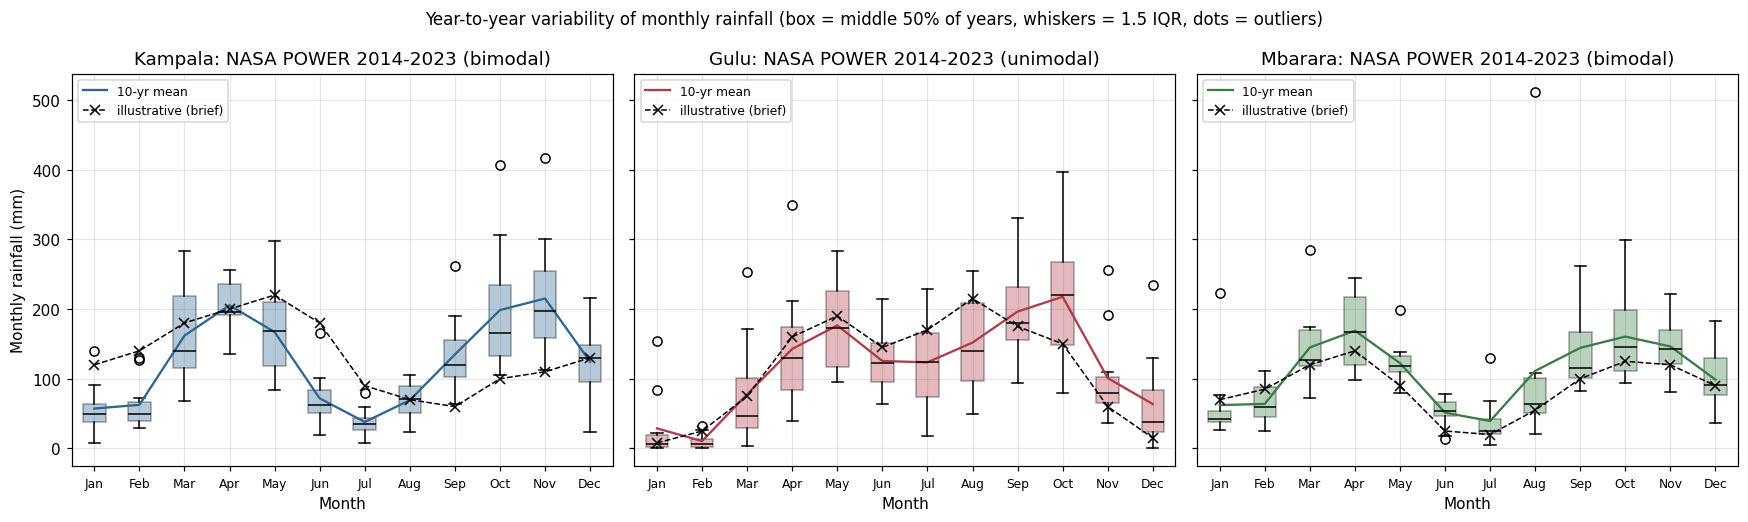

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, name in zip(axes, names):
    rec = records[name]
    ax.boxplot([rec.monthly[:, m] for m in range(12)], tick_labels=MONTHS, patch_artist=True,
               boxprops=dict(facecolor=COLORS[name], alpha=0.35), medianprops=dict(color="black"))
    ax.plot(range(1, 13), rec.climatology().rainfall, color=COLORS[name], lw=1.5, label="10-yr mean")
    ax.plot(range(1, 13), dict(zip(names, regions))[name].rainfall, "k--", marker="x", lw=1, label="illustrative (brief)")
    ax.set_title(f"{name}: NASA POWER 2014-2023 ({real[name].modality()})")
    ax.set_xlabel("Month"); ax.tick_params(axis="x", labelsize=8)
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("Monthly rainfall (mm)")
fig.suptitle("Year-to-year variability of monthly rainfall (box = middle 50% of years, whiskers = 1.5 IQR, dots = outliers)", fontsize=11)
fig.tight_layout(); fig.savefig("figures/p4_real_boxplots.png", bbox_inches="tight")
plt.show()

In [16]:
beans = rules[1]
reliability = pd.DataFrame({
    name: (rec.monthly >= beans.min_mm).mean(axis=0) for name, rec in records.items()
}, index=MONTHS).T
cv_table = pd.DataFrame({name: rec.monthly_cv() for name, rec in records.items()}, index=MONTHS).T
print(f"Share of the 10 years in which each month reached the beans minimum ({beans.min_mm:.0f} mm):")
display(reliability.style.format("{:.0%}").background_gradient(cmap="Greens", vmin=0, vmax=1))
print("Year-to-year CV of each month's rainfall:")
display(cv_table.round(2))

Share of the 10 years in which each month reached the beans minimum (80 mm):


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Kampala,20%,20%,90%,100%,100%,30%,0%,30%,90%,100%,100%,80%
Gulu,20%,0%,40%,80%,100%,90%,70%,90%,100%,90%,50%,30%
Mbarara,10%,40%,90%,100%,90%,0%,10%,40%,100%,100%,100%,70%


Year-to-year CV of each month's rainfall:


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Kampala,0.64,0.59,0.46,0.18,0.40,0.56,0.52,0.38,0.42,0.49,0.43,0.43
Gulu,1.76,1.05,1.03,0.63,0.38,0.35,0.54,0.46,0.35,0.43,0.69,1.13
Mbarara,0.93,0.46,0.42,0.34,0.27,0.41,0.92,1.29,0.45,0.40,0.31,0.46


**What the real data add.**

* **Seasonality check passes on real data.** With the same 30 % prominence rule, the detector finds **Kampala bimodal** (April and November peaks), **Mbarara bimodal** (April, October) and **Gulu unimodal** (one broad April–October season peaking in October, with a May shoulder). All three match Uganda's known zones. This confirms that the earlier Kampala "unimodal" result came from the illustrative data: real Kampala has dry January–February (≈ 60 mm, not 120–140) and wet October–November (≈ 200 mm, not 100–110). The low illustrative-vs-real correlation for Kampala shows the same thing.
* **Variability is large.** Rainy-season months vary by roughly 20–60 % (CV) from year to year, and Gulu's dry-season months by over 100 %. Annual totals ranged from 880 to 1,900 mm in Mbarara. A 12-number "average year" hides this: in Kampala, April is reliable (CV ≈ 0.18) while October's rain in a given year could be anything from 105 to 407 mm.
* **Outliers exist.** Mbarara's August 2022 value (≈ 512 mm) is far outside its other years. It is probably a reanalysis artefact or an extreme event, and it is a reminder to use medians or checks against gauge data before acting on a single value.
* **Reliability matters more than averages.** The reliability table (share of years that reached the beans minimum) turns rainfall into advice: in Mbarara, March–May and September–November reach 80 mm in 90–100 % of years, while June–July almost never do.

## Task 7 — Advisory note for farmers in Mbarara

> **Rainfall advisory — Mbarara district (bean and maize growers)**
>
> Mbarara has **two rainy seasons each year**, separated by a dry spell in **June–July** and a drier period in **January**.
>
> **Beans (best choice for both seasons).** Beans mature in about 3–3½ months and fit each season well.
> * *First season:* plant in the **first two weeks of March**, once the soil is moist to a hand's depth, and harvest in June as the rains stop.
> * *Second season:* plant in **early September** and harvest in December.
>
> Over the past ten years, March–May and September–November had enough rain for beans in at least 9 years out of 10.
>
> **Maize.** Maize needs 4–6 months, so it is better suited to the **second season**: plant in early September and harvest in January. Maize planted in March risks the June–July dry spell during grain filling.
>
> **Avoid** planting in June–July: rain is too low in almost every year.
>
> **Be flexible:** the same month can be twice as wet, or half as wet, from one year to the next. Wait for the rains to establish before planting, and listen to UNMA seasonal forecasts on local radio.

In [17]:
import re
advisory = [c.source for c in __import__("nbformat").read("project4_rainfall.ipynb", 4).cells if c.source.startswith("> **Rainfall advisory")]
if advisory:
    words = len(re.findall(r"[A-Za-z0-9½–'-]+", advisory[0]))
    print(f"Advisory note length: {words} words (limit 200)")

Advisory note length: 186 words (limit 200)


## Findings & Limitations

**Findings.** The three regions differ less in total rainfall (1,040–1,600 mm) than in *timing*, and timing is what decides planting. On the brief's data, Mbarara is bimodal with a June–July dry spell, Gulu is strongly seasonal with a December–February drought window, and Kampala is wet almost year-round with waterlogging risk in May. The choice of similarity measure changes the story. Cosine rates every pair as "similar" (≥ 0.75) because rainfall vectors are all-positive and cosine ignores magnitude: a region three times wetter scores 1.0. Pearson correlation, which centres the data first, shows that Kampala and Gulu have essentially unrelated seasonal timing. Cosine alone would therefore mislead an extension officer. Circular peak detection with a prominence threshold correctly separates true second seasons from shoulders, and on ten years of NASA POWER data it recovers Uganda's known pattern: bimodal south and centre, unimodal north. It also exposed a problem in the illustrative Kampala series, whose short rains are too weak to detect. The real data show that month-to-month reliability, not the average, should drive advice: Mbarara's bean seasons succeed in at least nine years out of ten.

**Limitations.** Crop thresholds are coarse conversions of seasonal water needs into monthly rainfall. They ignore effective rainfall, soil water storage, evapotranspiration and crop stage (flowering drought hurts more than early drought). Coffee's range comes from a handbook rather than field trials. NASA POWER is a gridded reanalysis at about 50 km resolution, not station data, and ten years is short for climate statistics. The "waterlogging" label depends on soil and drainage, which the model does not include.